In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

## Importando a base de músicas

In [20]:
caminho_arquivo = '../data/spotify_songs.csv'

# 1. Carregar os dados
df = pd.read_csv(caminho_arquivo)

# 2. Definir quem é texto (Rótulo) e quem é número (Feature)
coluna_rotulo = 'track_genre' # Usaremos isso para definir se é similar (Y=1) ou não (Y=0)
colunas_features = [
            'danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo'
        ]

## Limpeza do dataset: removendo duplicatas

Percebemos ao abrir o dataset em uma planilha que havia muitas músicas repetidas com IDs diferentes, pois o Spotify indica um ID distindo para músicas iguais que são republicadas em albuns diferentes, por exemplo. Tendo em vista isso fizemos uma limpeza nessas duplicatas.

In [21]:
print(f"Quantidade de músicas antes da limpeza: {df.shape[0]}")

df_limpo = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

print(f"Quantidade de músicas após a limpeza: {df_limpo.shape[0]}")

df = df_limpo.reset_index(drop=True)

Quantidade de músicas antes da limpeza: 114000
Quantidade de músicas após a limpeza: 81344


## Normalizando a matriz das features

In [22]:
# Normalizar apenas os números
scaler = MinMaxScaler()
df[colunas_features] = scaler.fit_transform(df[colunas_features])

print("Dados normalizados e prontos!")

df.head()

Dados normalizados e prontos!


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.686294,0.4610,...,0.791392,0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.426396,0.1660,...,0.597377,1,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.444670,0.3590,...,0.736123,1,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.270051,0.0596,...,0.573701,1,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.627411,0.4430,...,0.737103,1,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,4,acoustic


## Construindo o modelo da Rede Siamesa


In [23]:
# 1. Definindo os Hiperparâmetros Fixos
BATCH_SIZE = 64
EMBEDDING_DIM = 32
MARGIN = 2.0
LEARNING_RATE = 0.001 
HIDDEN_SIZE = 64
INPUT_SIZE = 9

# 2. A Arquitetura da Rede Siamesa (As "Gêmeas")
class SiameseNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, embedding_dim):
        super(SiameseNetwork, self).__init__()
        # Camadas ocultas da rede. Ela recebe as features e as reduz até o Embedding.
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, embedding_dim) # O vetor final de tamanho 32
        
    def forward_once(self, x):
        # Esta é UMA "perna" da rede. Ela processa uma música por vez.
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        
    def forward(self, input1, input2):
        # Passa a Música A e a Música B pela mesma rede (pesos compartilhados)
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

# 3. A Função de Punição (Contrastive Loss)
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Calcula a distância geométrica (euclidiana) entre as duas músicas
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=False)
        
        # Aplica a fórmula de penalização usando a Margem
        # label=1 (similares), label=0 (diferentes)
        loss_contrastive = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                                      (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

# 4. Inicializando tudo para o Treinamento
modelo = SiameseNetwork(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, embedding_dim=EMBEDDING_DIM)
criterio_perda = ContrastiveLoss(margin=MARGIN)

# Conectando o otimizador Adam ao nosso modelo com a taxa de 0.001
otimizador = torch.optim.Adam(modelo.parameters(), lr=LEARNING_RATE)

print("Rede Siamesa inicializada com sucesso e pronta para receber os dados!")

Rede Siamesa inicializada com sucesso e pronta para receber os dados!


## Separando pares para treinamento e teste

In [24]:
def gerar_pares_siameses(df, features, label_col, total_pares):
    # Dicionário rápido para achar as linhas de cada subgênero
    indices_por_genero = df.groupby(label_col).groups
    lista_generos = list(indices_por_genero.keys())
    
    pares_X1 = []
    pares_X2 = []
    labels_Y = []
    
    # Metade dos pares serão SIMILARES (Y = 1)
    for _ in range(total_pares // 2):
        # 1. Sorteia um gênero
        genero_escolhido = random.choice(lista_generos)
        
        # 2. Pega duas músicas diferentes que têm esse MESMO gênero
        idx1, idx2 = random.sample(list(indices_por_genero[genero_escolhido]), 2)
        
        pares_X1.append(df.loc[idx1, features].values)
        pares_X2.append(df.loc[idx2, features].values)
        labels_Y.append(1.0) # 1 = Similares
        
    # Outra metade será de DIFERENTES (Y = 0)
    for _ in range(total_pares // 2):
        # 1. Sorteia DOIS gêneros diferentes (ex: Rock e Pop)
        genero_A, genero_B = random.sample(lista_generos, 2)
        
        # 2. Pega uma música de cada
        idx1 = random.choice(list(indices_por_genero[genero_A]))
        idx2 = random.choice(list(indices_por_genero[genero_B]))
        
        pares_X1.append(df.loc[idx1, features].values)
        pares_X2.append(df.loc[idx2, features].values)
        labels_Y.append(0.0) # 0 = Diferentes
        
    # Converte tudo para matrizes do Numpy para o PyTorch conseguir ler depois
    return np.array(pares_X1, dtype=np.float32), np.array(pares_X2, dtype=np.float32), np.array(labels_Y, dtype=np.float32)

# Rodando a função!
# X1_treino, X2_treino, Y_treino = gerar_pares_siameses(df, colunas_features, coluna_rotulo, total_pares=2* df.shape[0]//3)

# print(f"Gerados {len(X1_treino)} pares de músicas no total!")
# print(f"Formato da Música 1: {X1_treino.shape} ({2* df.shape[0]//3} pares, X features)")

In [25]:
df_treino, df_teste = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df[coluna_rotulo] 
)

# 2. CRUCIAL: Resetar os índices para a função gerar_pares_siameses funcionar
df_treino = df_treino.reset_index(drop=True)
df_teste = df_teste.reset_index(drop=True)

print(f"Músicas para Treinar a rede: {df_treino.shape[0]}")
print(f"Músicas separadas para Testar a rede: {df_teste.shape[0]}")

# ==========================================================
# 3. Agora você chama a sua função duas vezes separadamente!
# ==========================================================

# Gera os pares de TREINO (Ex: 20.000 pares usando só as músicas de treino)
X1_treino, X2_treino, Y_treino = gerar_pares_siameses(
    df_treino, 
    colunas_features, 
    coluna_rotulo, 
    total_pares=len(df_treino)
)

# Gera os pares de TESTE (Ex: 4.000 pares usando SOMENTE as músicas isoladas do teste)
X1_teste, X2_teste, Y_teste = gerar_pares_siameses(
    df_teste, 
    colunas_features, 
    coluna_rotulo, 
    total_pares=len(df_teste)
)

print("\nSeparação concluída com sucesso!")
print(f"Pares de Treino gerados: {len(X1_treino)}")
print(f"Pares de Teste gerados: {len(X1_teste)}")

Músicas para Treinar a rede: 65075
Músicas separadas para Testar a rede: 16269

Separação concluída com sucesso!
Pares de Treino gerados: 65074
Pares de Teste gerados: 16268


## Treinando nossa Rede Siamesa

In [26]:
# 1. Convertendo as matrizes Numpy para Tensores do PyTorch
tensor_x1 = torch.tensor(X1_treino, dtype=torch.float32)
tensor_x2 = torch.tensor(X2_treino, dtype=torch.float32)
tensor_y = torch.tensor(Y_treino, dtype=torch.float32)

# 2. Criando o Dataset e o DataLoader (fatiando em lotes de 32 e embaralhando)
dataset = TensorDataset(tensor_x1, tensor_x2, tensor_y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [27]:
EPOCHS = 50
historico_loss = []

# Avisa o PyTorch que o modelo está no modo "Estudante/Treinamento"
modelo.train() 

print("Iniciando o treinamento da Rede Siamesa...")

for epoca in range(EPOCHS):
    loss_total_epoca = 0.0
    
    # O loop mastiga lote por lote (32 pares por vez)
    for batch_x1, batch_x2, batch_y in dataloader:
        
        # 1. Zera a memória de erros do passo anterior
        otimizador.zero_grad()
        
        # 2. Forward Pass: A rede gera os embeddings (os vetores de 32 dimensões)
        out1, out2 = modelo(batch_x1, batch_x2)
        
        # 3. Calcula o Erro: Distância entre os vetores vs O Gabarito (batch_y)
        loss = criterio_perda(out1, out2, batch_y)
        
        # 4. Backpropagation: Descobre quais neurônios causaram o erro
        loss.backward()
        
        # 5. Otimizador Adam: Corrige os pesos matemáticos
        otimizador.step()
        
        loss_total_epoca += loss.item()
        
    # Tira a média de erro da época e guarda para o gráfico
    loss_media = loss_total_epoca / len(dataloader)
    historico_loss.append(loss_media)
    
    print(f"Época {epoca+1}/{EPOCHS} concluída | Erro Médio (Loss): {loss_media:.4f}")

Iniciando o treinamento da Rede Siamesa...
Época 1/50 concluída | Erro Médio (Loss): 0.8805
Época 2/50 concluída | Erro Médio (Loss): 0.8469
Época 3/50 concluída | Erro Médio (Loss): 0.8400
Época 4/50 concluída | Erro Médio (Loss): 0.8366
Época 5/50 concluída | Erro Médio (Loss): 0.8344
Época 6/50 concluída | Erro Médio (Loss): 0.8322
Época 7/50 concluída | Erro Médio (Loss): 0.8312
Época 8/50 concluída | Erro Médio (Loss): 0.8294
Época 9/50 concluída | Erro Médio (Loss): 0.8284
Época 10/50 concluída | Erro Médio (Loss): 0.8276
Época 11/50 concluída | Erro Médio (Loss): 0.8262
Época 12/50 concluída | Erro Médio (Loss): 0.8256
Época 13/50 concluída | Erro Médio (Loss): 0.8251
Época 14/50 concluída | Erro Médio (Loss): 0.8244
Época 15/50 concluída | Erro Médio (Loss): 0.8238
Época 16/50 concluída | Erro Médio (Loss): 0.8238
Época 17/50 concluída | Erro Médio (Loss): 0.8233
Época 18/50 concluída | Erro Médio (Loss): 0.8222
Época 19/50 concluída | Erro Médio (Loss): 0.8212
Época 20/50 conc

## Visualizando a curva da contrastive loss

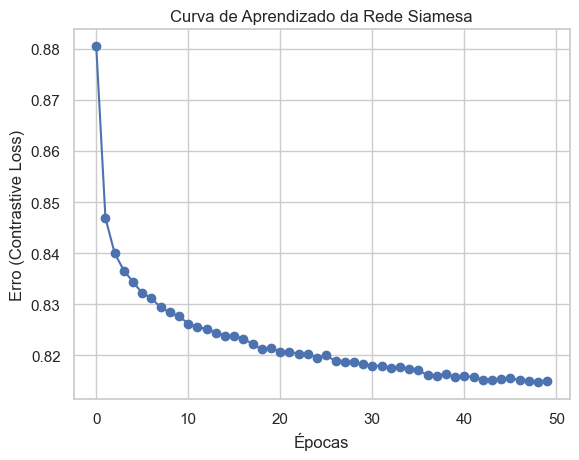

In [28]:
plt.plot(historico_loss, marker='o')
plt.title("Curva de Aprendizado da Rede Siamesa")
plt.xlabel("Épocas")
plt.ylabel("Erro (Contrastive Loss)")
plt.show()

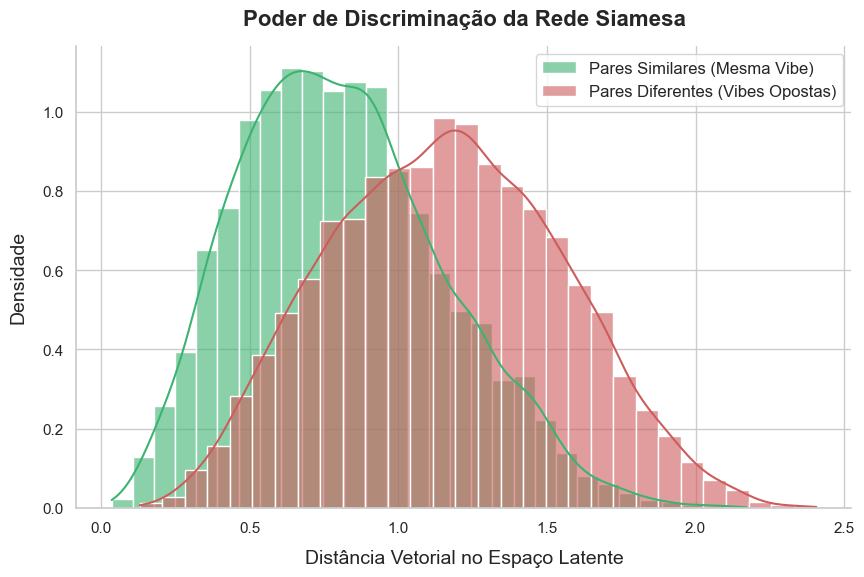

In [29]:
tensor_teste_X1 = torch.tensor(X1_teste, dtype=torch.float32)
tensor_teste_X2 = torch.tensor(X2_teste, dtype=torch.float32)

modelo.eval() # Garante que o modelo está em modo de avaliação
with torch.no_grad(): # Desliga o cálculo de gradientes para economizar memória e ficar super rápido
    embeddings_tensor_X1 = modelo.forward_once(tensor_teste_X1)
    embeddings_tensor_X2 = modelo.forward_once(tensor_teste_X2)

emb_X1_np = embeddings_tensor_X1.numpy()
emb_X2_np = embeddings_tensor_X2.numpy()

distancias = np.linalg.norm(emb_X1_np - emb_X2_np, axis=1)

distancias_similares = distancias[Y_teste == 1.0]
distancias_diferentes = distancias[Y_teste == 0.0]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plota a curva das músicas SIMILARES (em Verde)
sns.histplot(
    distancias_similares, 
    color="mediumseagreen", 
    label="Pares Similares (Mesma Vibe)", 
    kde=True,          # Adiciona a linha de contorno suave
    stat="density",    # Normaliza o gráfico
    alpha=0.6,         # Transparência
    bins=30
)

# Plota a curva das músicas DIFERENTES (em Vermelho)
sns.histplot(
    distancias_diferentes, 
    color="indianred", 
    label="Pares Diferentes (Vibes Opostas)", 
    kde=True, 
    stat="density", 
    alpha=0.6,
    bins=30
)

# Embelezamento do gráfico para a Apresentação
plt.title('Poder de Discriminação da Rede Siamesa', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Distância Vetorial no Espaço Latente', fontsize=14, labelpad=10)
plt.ylabel('Densidade', fontsize=14, labelpad=10)
plt.legend(fontsize=12, loc='upper right')

# Remove as bordas feias de cima e da direita
sns.despine()

# Salva a imagem em alta resolução para colar no slide
plt.savefig('histograma_distancias_siamesa.png', dpi=300, bbox_inches='tight')

# Mostra o gráfico na tela
plt.show()

## Construindo nosso buscador de recomendações

In [30]:
# 1. Pegar TODAS as features do dataframe escalonado
todas_as_features = df[colunas_features].astype(float).values

# 2. Converter a matriz inteira para um Tensor do PyTorch
tensor_todas_features = torch.tensor(todas_as_features, dtype=torch.float32)

# 3. Passar a matriz gigante pela rede para gerar os embeddings
modelo.eval() # Garante que o modelo está em modo de avaliação
with torch.no_grad(): # Desliga o cálculo de gradientes para economizar memória e ficar super rápido
    embeddings_tensor = modelo.forward_once(tensor_todas_features)

# 4. Converter o resultado para Numpy Array (O Scikit-learn precisa de Numpy, não Tensores)
embeddings_siamesa = embeddings_tensor.numpy()

print(f"Matriz de embeddings gerada! Formato: {embeddings_siamesa.shape}")
# O formato deve ser algo como (N, 32), onde N é o total de músicas únicas e 32 é o EMBEDDING_DIM

# 5. Inicializar e treinar o Buscador KNN
buscador = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
buscador.fit(embeddings_siamesa)
print("Buscador KNN treinado com os embeddings!")

Matriz de embeddings gerada! Formato: (81344, 32)
Buscador KNN treinado com os embeddings!


## Avaliando recomendações

### Recomendações puramente matemáticas

In [43]:
lista_track_positions = df.index.tolist()

In [44]:
# Música fixa da Taylor Swift
indices_encontrados = df.index[df['track_id'] == '55n9yjI6qqXh5F2mYvUc2y'].tolist()
id_musica_base = indices_encontrados[0]

# 1. Sorteia uma linha aleatória baseada no total de músicas que temos
# linha_musica_base = random.randint(0, len(lista_track_positions) - 1)
# id_musica_base = lista_track_positions[linha_musica_base]
vetor_musica_base = embeddings_siamesa[id_musica_base]

# 2. Busca os detalhes da música base (a que foi sorteada) para exibição
nome_base = df.loc[id_musica_base, 'track_name']
artista_base = df.loc[id_musica_base, 'artists']
genero_base = df.loc[id_musica_base, 'track_genre']

# 3. O buscador encontra os vizinhos mais próximos
distancias, indices = buscador.kneighbors([vetor_musica_base])

# --- EXIBIÇÃO DOS RESULTADOS ---
print("="*60)
print(f"MÚSICA SORTEADA (BASE):")
print(f"{nome_base} - {artista_base}")
print(f"Gênero original: {genero_base}")
print(f"Track ID: {id_musica_base}")
print("="*60)

# O índice 0 é a própria música, então iteramos a partir do índice 1
print("\nRECOMENDAÇÕES ENCONTRADAS:")
for i in range(1,6 ):
    linha_recomendada = indices[0][i]
    print(f"Linha recomenda: {linha_recomendada}")
    id_recomendado = lista_track_positions[linha_recomendada]
    distancia_calc = distancias[0][i]
    
    # Buscando o nome, artista e gênero da música recomendada
    nome = df.loc[id_recomendado, 'track_name']
    artista = df.loc[id_recomendado, 'artists']
    genero = df.loc[id_recomendado, 'track_genre']
    
    print(f"{i}º -> {nome} - {artista}")
    print(f"      Gênero: {genero} | Distância: {distancia_calc:.4f}\n")

MÚSICA SORTEADA (BASE):
I Don’t Wanna Live Forever (Fifty Shades Darker) - ZAYN;Taylor Swift
Gênero original: dance
Track ID: 17239

RECOMENDAÇÕES ENCONTRADAS:
Linha recomenda: 79677
1º -> Lanet - Arda Gezer;Şehinşah;Caner Özgür
      Gênero: turkish | Distância: 0.0073

Linha recomenda: 52835
2º -> Neethan - MC Qiru;Nirujan;Vernon G Segaram
      Gênero: malay | Distância: 0.0106

Linha recomenda: 79788
3º -> fanus - Mavi;Defa
      Gênero: turkish | Distância: 0.0109

Linha recomenda: 73321
4º -> Drama (feat. Drake) - Roy Woods;Drake
      Gênero: soul | Distância: 0.0113

Linha recomenda: 73365
5º -> Drama - Roy Woods;Drake
      Gênero: soul | Distância: 0.0117



### Recomendações matemáticas com filtro de gênero

In [45]:
# Música fixa da Taylor Swift
indices_encontrados = df.index[df['track_id'] == '55n9yjI6qqXh5F2mYvUc2y'].tolist()
id_musica_base = indices_encontrados[0]

# 1. Sorteia uma linha aleatória baseada no total de músicas que temos
# linha_musica_base = random.randint(0, len(lista_track_positions) - 1)
# id_musica_base = lista_track_positions[linha_musica_base]
vetor_musica_base = embeddings_siamesa[id_musica_base]
print("Embedding:", vetor_musica_base[:5])
# 2. Busca os detalhes da música base (a que foi sorteada) para exibição
nome_base = df.loc[id_musica_base, 'track_name']
artista_base = df.loc[id_musica_base, 'artists']
genero_base = df.loc[id_musica_base, 'track_genre']

# 3. Encontra a posição (linha) de todas as músicas que possuem esse mesmo gênero
indices_mesmo_genero = [i for i, tid in enumerate(lista_track_positions) if df.loc[tid, 'track_genre'] == genero_base]

# 4. Filtra a matriz gigante para ter SÓ as músicas dessa bolha
embeddings_filtrados = embeddings_siamesa[indices_mesmo_genero]
lista_ids_filtrada = [lista_track_positions[i] for i in indices_mesmo_genero]

# 5. Cria e treina o buscador temporário instantaneamente
buscador_nicho = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
buscador_nicho.fit(embeddings_filtrados)

# 6. O buscador encontra os vizinhos mais próximos APENAS dentro do nicho
distancias, indices = buscador_nicho.kneighbors([vetor_musica_base])

# --- EXIBIÇÃO DOS RESULTADOS ---
print("="*60)
print(f"MÚSICA SORTEADA (BASE):")
print(f"{nome_base} - {artista_base}")
print(f"Gênero original: {genero_base}")
print(f"Track ID: {id_musica_base}")
print("="*60)

# O índice 0 é a própria música, então iteramos a partir do índice 1
print("\nRECOMENDAÇÕES ENCONTRADAS (SOMENTE MESMO GÊNERO):")
for i in range(1, 6):
    linha_recomendada = indices[0][i]
    
    id_recomendado = lista_ids_filtrada[linha_recomendada] 
    distancia_calc = distancias[0][i]
    
    # Buscando o nome, artista e gênero da música recomendada
    nome = df.loc[id_recomendado, 'track_name']
    artista = df.loc[id_recomendado, 'artists']
    genero = df.loc[id_recomendado, 'track_genre']
    
    print(f"{i}º -> {nome} - {artista}")
    print(f"      Gênero: {genero} | Distância: {distancia_calc:.4f}\n")

Embedding: [-0.47571653  0.61602336  0.2979989  -0.11737882 -0.18806118]
MÚSICA SORTEADA (BASE):
I Don’t Wanna Live Forever (Fifty Shades Darker) - ZAYN;Taylor Swift
Gênero original: dance
Track ID: 17239

RECOMENDAÇÕES ENCONTRADAS (SOMENTE MESMO GÊNERO):
1º -> Here With Me - Marshmello;CHVRCHES
      Gênero: dance | Distância: 0.0150

2º -> Spicy - Ty Dolla $ign;Post Malone
      Gênero: dance | Distância: 0.0164

3º -> One Last Time - Ariana Grande
      Gênero: dance | Distância: 0.0271

4º -> Shower - Becky G
      Gênero: dance | Distância: 0.0280

5º -> Let Me Love You - DJ Snake;Justin Bieber
      Gênero: dance | Distância: 0.0284



## Salvando nosso modelo treinado

In [46]:
lista_track_ids = df['track_id'].tolist()
lista_generos = df['track_genre'].tolist()


caminho_matriz_embeddings = '../backend/models/todos_os_embeddings.npy'
caminho_lista_generos = '../backend/models/todos_os_generos.pkl'
caminho_buscador = '../backend/models/buscador_knn.pkl'
caminho_lista_track_ids = '../backend/models/lista_track_ids.pkl'
caminho_siamesa = '../backend/models/rede_siamesa.pth'
caminho_scaler_siamesa = '../backend/models/scaler_siamesa.pkl'

joblib.dump(buscador, caminho_buscador)
joblib.dump(lista_track_ids, caminho_lista_track_ids)
torch.save(modelo.state_dict(), caminho_siamesa)
np.save(caminho_matriz_embeddings, embeddings_siamesa)
joblib.dump(lista_generos, caminho_lista_generos)
joblib.dump(scaler, caminho_scaler_siamesa)

print("Matriz de embeddings (.npy) e lista de gêneros (.pkl) salvas com sucesso!")
print("Arquivos 'buscador_knn.pkl' e 'lista_track_ids.pkl' salvos com sucesso!")

Matriz de embeddings (.npy) e lista de gêneros (.pkl) salvas com sucesso!
Arquivos 'buscador_knn.pkl' e 'lista_track_ids.pkl' salvos com sucesso!
